# Classificação: Validação de modelos e métricas de avaliação

### Projeto

Uma empresa de empréstimo de automóveis está passando por uma situação complicada, com alta demanda para uma frota reduzida de veículos e alto número de inadimplentes, trazendo um prejuízo grande para a empresa.

Nós fomos contratados para buscar melhorias na identificação de inadimplentes. A análise dos clientes atualmente é feita de forma manual, cliente por cliente, tomando muito tempo e ainda assim a detecção de inadimplentes é muito imprecisa.

Nossa tarefa é utilizar os dados fornecidos pela empresa para **classificar** os clientes em adimplentes e inadimplentes.

In [ ]:
import pandas as pd
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_validate, KFold, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, roc_auc_score, PrecisionRecallDisplay, average_precision_score, classification_report
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import make_scorer, recall_score
from imblearn.combine import SMOTEENN

## Classificando dados

### Criando um modelo inicial

In [ ]:
dados = pd.read_csv('https://cdn3.gnarususercontent.com.br/3069-classificacao/emp_automovel.csv')
dados

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000,1
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000,1
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056,1
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000,1


In [ ]:
x = dados.drop(columns='inadimplente')
y = dados['inadimplente']

In [ ]:
modelo = DecisionTreeClassifier()
modelo.fit(x, y)
modelo.score(x, y)

1.0

In [ ]:
print(f'Acurácia: {modelo.score(x, y) * 100:.2f}%')

Acurácia: 100.00%


### Validando o modelo

Avaliar os modelo com base nos mesmos dados usados no treinamento não é interessante. É preciso que a avaliação seja feita em dados independentes.

Avaliar o modelo nos próprios dados de treinamento seria o análogo a entregar uma prova com as questões e o gabarito para uma pessoa e no momento de avaliá-la novamente, entregar uma prova com as mesmas questões e alternativas. É esperado que essa pessoa se sairá bem por já ter visto as respostas e ter decorado o resultado. Isso é diferente de ter aprendido a matéria a partir daquela prova e depois fazer uma prova com conteúdo parecido e ter um resultado positivo.

No intuito de checar a generalização de um modelo, devemos separar o conjunto de dados em 3 partes: dados de treinamento, validação e teste.

- o conjunto de treinamento é utilizado para treinar os modelos. Os modelos vão entender o padrão dos dados a partir desse conjunto de dados.

- o conjunto de validação é utilizado para avaliar o desempenho de diferentes modelos, com dados novos que não foram usados no treinamento do modelo.

- o conjunto de teste fica separado dos demais desde o momento inicial para simular os dados do mundo real. Ele não é utilizado em nenhum momento no treinamento e nem na validação, servindo como uma estimativa da capacidade do modelo escolhido de generalizar e prever novos dados.

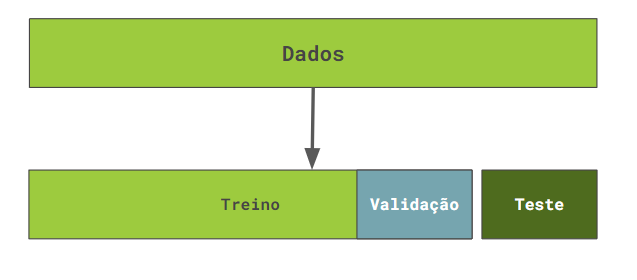

In [ ]:
x, x_teste, y, y_teste = train_test_split(x, y, test_size=0.15, stratify=y, random_state=5)
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify=y, random_state=5)

In [ ]:
modelo = DecisionTreeClassifier()
modelo.fit(x_treino, y_treino)

print(f'Acurácia de treino: {modelo.score(x_treino, y_treino) * 100:.2f}%')
print(f'Acurácia de validação: {modelo.score(x_val, y_val) * 100:.2f}%')

Acurácia de treino: 100.00%
Acurácia de validação: 84.92%


In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_treino, y_treino)

print(f'Acurácia de treino: {modelo.score(x_treino, y_treino) * 100:.2f}%')
print(f'Acurácia de validação: {modelo.score(x_val, y_val) * 100:.2f}%')

Acurácia de treino: 92.06%
Acurácia de validação: 90.56%


### Avaliando o modelo

In [ ]:
y_previsto = modelo.predict(x_val)

matriz_confusao = confusion_matrix(y_val, y_previsto)
matriz_confusao

array([[10355,   124],
       [  960,    42]])

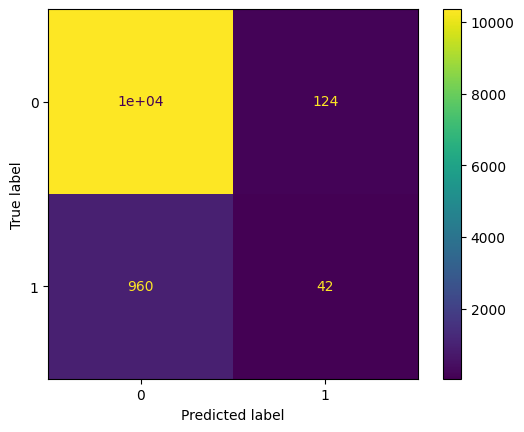

In [ ]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualizacao.plot();

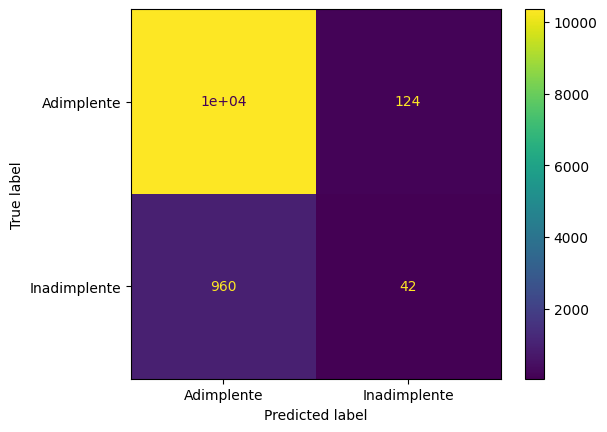

In [ ]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
visualizacao.plot();

### Desafio: construindo um segundo modelo

In [ ]:
modelo_desafio = RandomForestClassifier(random_state=5)
modelo_desafio.fit(x_treino, y_treino)

print(f'Acurácia de treino: {modelo_desafio.score(x_treino, y_treino) * 100:.2f}%')
print(f'Acurácia de validação: {modelo_desafio.score(x_val, y_val) * 100:.2f}%')

Acurácia de treino: 100.00%
Acurácia de validação: 91.57%


In [ ]:
modelo_desafio = RandomForestClassifier(max_depth=10, random_state=5)
modelo_desafio.fit(x_treino, y_treino)

print(f'Acurácia de treino: {modelo_desafio.score(x_treino, y_treino) * 100:.2f}%')
print(f'Acurácia de validação: {modelo_desafio.score(x_val, y_val) * 100:.2f}%')

Acurácia de treino: 91.54%
Acurácia de validação: 91.30%


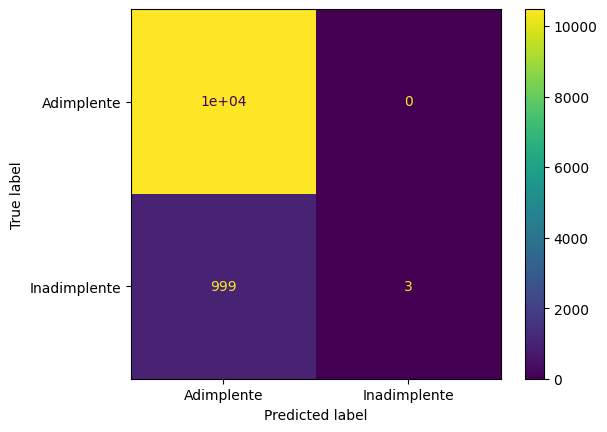

In [ ]:
matriz_confusao_desafio = confusion_matrix(y_val, modelo_desafio.predict(x_val))

ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_desafio, display_labels=['Adimplente', 'Inadimplente']).plot();

## Métricas de avaliação

### Acurácia, Precisão, Recall e F1-Score

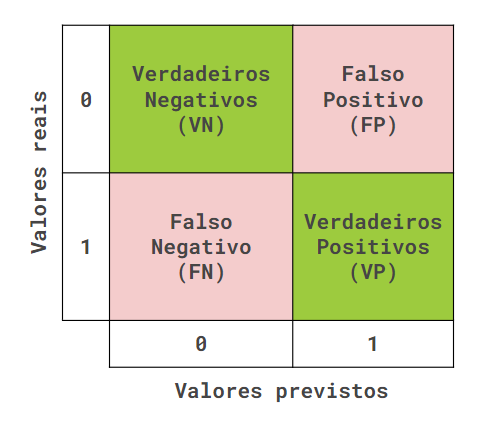

In [ ]:
print(f"Acurácia: {accuracy_score(y_val, y_previsto)}%")

Acurácia: 90.56%


In [ ]:
print(f"Precisão: {precision_score(y_val, y_previsto)}%")
print(f"Recall: {recall_score(y_val, y_previsto)}%")

Precisão: 0.25301204819277107%
Recall: 0.041916167664670656%


In [ ]:
print(f"F1-Score: {f1_score(y_val, y_previsto)}%")

F1-Score: 0.07191780821917808%


### Curva ROC

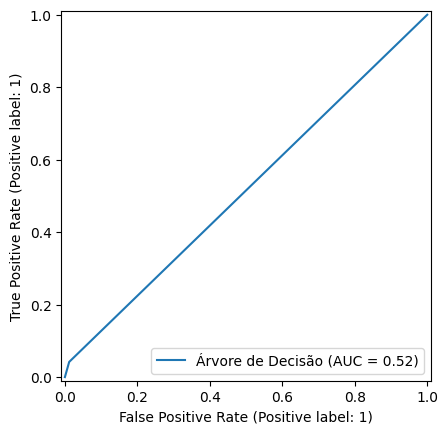

In [ ]:
RocCurveDisplay.from_predictions(y_val, y_previsto, name='Árvore de Decisão');

In [ ]:
print(f"AUC: {roc_auc_score(y_val, y_previsto)}")

AUC: 0.5150414887373835


### Curva de Precisão x Recall

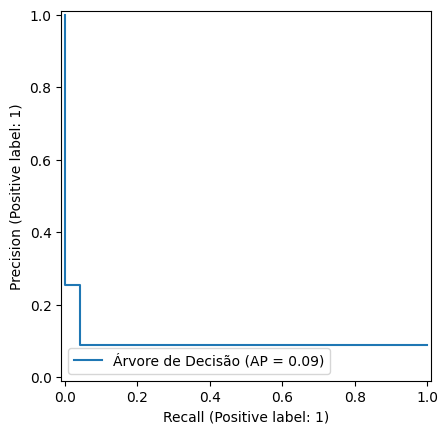

In [ ]:
PrecisionRecallDisplay.from_predictions(y_val, y_previsto, name='Árvore de Decisão');

In [ ]:
print(f"AP: {average_precision_score(y_val, y_previsto)}")

AP: 0.09422170515363755


### Relatório de métricas

In [ ]:
print(classification_report(y_val, y_previsto))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.25      0.04      0.07      1002

    accuracy                           0.91     11481
   macro avg       0.58      0.52      0.51     11481
weighted avg       0.86      0.91      0.87     11481



## Validação cruzada

A validação do modelo de classificação a partir da separação dos dados em conjunto de treino e validação faz com que o resultado seja muito dependente dessa divisão dos dados e pode ser que, de forma aleatória, o padrão dos dados de validação sejam diferentes do padrão dos dados de treinamento, levando a sorte de ter um resultado muito melhor do que a realidade ou o azar de um resultado muito pior do que a realidade.

Levando isso em consideração, é possível utilizar a **validação cruzada**, uma estratégia mais consistente e bem mais utilizada nos projetos de machine learning.

Na validação cruzada, ao invés de separarmos os dados em apenas treino e validação uma única vez, dividimos os dados em várias partes de mesmo tamanho. Em cada uma dessas divisões, será utilizada uma parte para validação e todas as outras para treinamento e o processo se repete até que todas as partes sejam utilizadas para validação e o restante para treinamento.

Será gerado um modelo para cada uma dessas divisões e a avaliação de desempenho será feita tirando a média da métrica de cada modelo. Isso faz com que a dependência da separação dos dados seja eliminada, já que há uma variação maior da escolha dos dados e é retirada uma média.

Geralmente são utilizadas 5 ou 10 partes, mais do que isso não é tão necessário porque necessita de um processamento maior e valores menores já mitiga o problema da escolha dos dados.

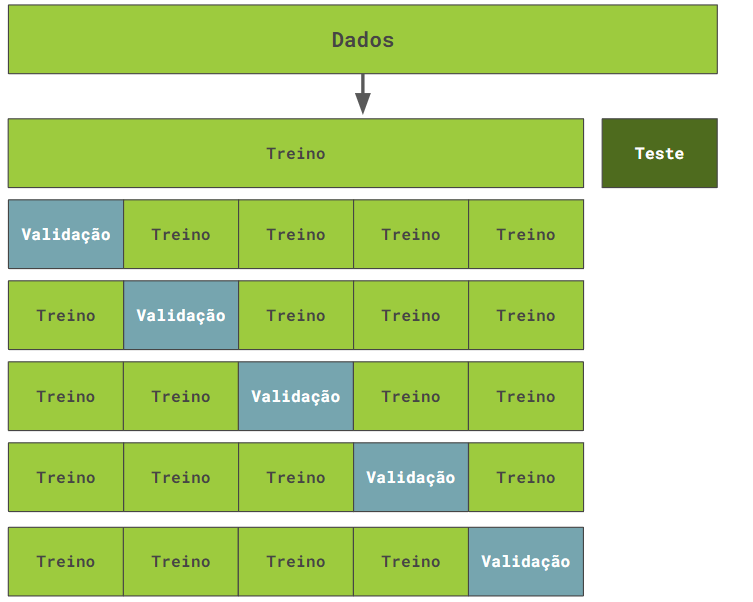

In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)

kf = KFold(n_splits=5, shuffle=True, random_state=5)

cv_resultados = cross_validate(modelo, x, y, cv=kf)
cv_resultados

{'fit_time': array([0.26047683, 0.26646614, 0.24518585, 0.31154013, 0.34802365]),
 'score_time': array([0.00364208, 0.00344348, 0.00352073, 0.00517249, 0.00577307]),
 'test_score': array([0.91301034, 0.90712108, 0.90733885, 0.9135453 , 0.8997169 ])}

In [ ]:
media = cv_resultados['test_score'].mean()
desvio_padrao = cv_resultados['test_score'].std()

print(f"Intervalo de confiança: [{media - 2 * desvio_padrao} - {media + 2 * desvio_padrao}]")

Intervalo de confiança: [0.8981238821925 - 0.9181691051619012]


### Validação cruzada com recall

In [ ]:
def intervalo_conf(resultados):
  media = resultados['test_score'].mean()
  desvio_padrao = resultados['test_score'].std()

  print(f"Intervalo de confiança: [{media - 2 * desvio_padrao} - {media + 2 * desvio_padrao}]")

In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)

kf = KFold(n_splits=5, shuffle=True, random_state=5)

cv_resultados = cross_validate(modelo, x, y, cv=kf, scoring='recall')
cv_resultados

{'fit_time': array([0.25165892, 0.24858761, 0.25386524, 0.24579167, 0.25301361]),
 'score_time': array([0.00722671, 0.00576282, 0.00560164, 0.00561213, 0.00600696]),
 'test_score': array([0.02377807, 0.01732673, 0.02091021, 0.01697128, 0.02427746])}

In [ ]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.014482626057875276 - 0.026822873594260468]


### Estratificando os dados

In [ ]:
dados['inadimplente'].value_counts(normalize=True)

,proportion
inadimplente,
0,0.912707
1,0.087293


In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

cv_resultados = cross_validate(modelo, x, y, cv=skf, scoring='recall')

In [ ]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.017344788533542196 - 0.03753050762057937]


### Desafio: validação com outras métricas

In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle=True, random_state=5)

cv_resultados = cross_validate(modelo, x, y, cv=kf, scoring=['accuracy', 'precision', 'recall', 'f1'])
pd.DataFrame(cv_resultados)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,0.247078,0.012568,0.913337,0.259259,0.027741,0.050119
1,0.310431,0.024843,0.907339,0.213333,0.019802,0.036240
2,0.401727,0.056170,0.907448,0.239437,0.020910,0.038462
3,0.903933,0.047936,0.914090,0.274510,0.018277,0.034272
4,0.744099,0.045614,0.898737,0.190476,0.023121,0.041237


In [ ]:
def relatorio_metricas(resultados):
  for metrica in ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']:
    media = resultados[metrica].mean()
    desvio_padrao = resultados[metrica].std()

    print(f"Intervalo de confiança ({metrica}): [{media - 2 * desvio_padrao} - {media + 2 * desvio_padrao}]")

In [ ]:
relatorio_metricas(cv_resultados)

Intervalo de confiança (test_accuracy): [0.8971652029069151 - 0.9192148782358359]
Intervalo de confiança (test_precision): [0.17460684601607177 - 0.29619923666739295]
Intervalo de confiança (test_recall): [0.015391861262595789 - 0.028548707620878726]
Intervalo de confiança (test_f1): [0.028994321339046322 - 0.05113759867385913]


## Balanceamento de dados

### Oversampling

In [ ]:
oversample = SMOTE()

x_balanceado, y_balanceado = oversample.fit_resample(x, y)

In [ ]:
y_balanceado.value_counts(normalize=True)

,proportion
inadimplente,
0,0.5
1,0.5


In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

cv_resultados = cross_validate(modelo, x_balanceado, y_balanceado, cv=skf, scoring='recall')

In [ ]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.6964403087805281 - 0.7719691163570336]


### Pipeline para validação

In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)

pipeline = imbpipeline([('oversample', SMOTE()), ('arvore', modelo)])

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring='recall')

In [ ]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.19931722899637652 - 0.30454048003939865]


### Undersampling

In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)

pipeline = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', modelo)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring='recall')

In [ ]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.6212571722234411 - 0.7032455534841376]


## Testando o modelo

              precision    recall  f1-score   support

           0       0.94      0.48      0.64      7397
           1       0.11      0.70      0.20       707

    accuracy                           0.50      8104
   macro avg       0.53      0.59      0.42      8104
weighted avg       0.87      0.50      0.60      8104



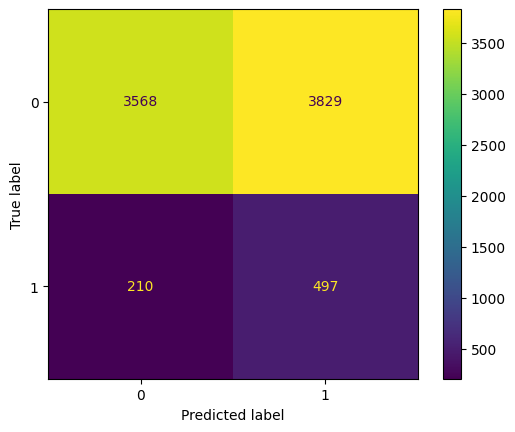

In [ ]:
undersample = NearMiss(version=3)
x_balanceado, y_balanceado = undersample.fit_resample(x, y)

modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_balanceado, y_balanceado)
y_previsto = modelo.predict(x_teste)

print(classification_report(y_teste, y_previsto))
ConfusionMatrixDisplay.from_predictions(y_teste, y_previsto);

### Desafio: outros métodos de balanceamento

In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
pipeline = imbpipeline([('smoteenn', SMOTEENN()), ('arvore', modelo)])

cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring='recall')

intervalo_conf(cv_resultados)

Intervalo de confiança: [0.22624692125029705 - 0.46924157349287005]


# Desafio

Vamos praticar o conteúdo que foi apresentado na aula a partir de algumas atividades, porém usando um conjunto de dados diferente com dados de pacientes a serem diagnosticados com diabetes ou não.

## Classificando dados

1. Para a construção de um modelo de machine learning são necessários dados. Como tarefa inicial, faça a leitura da base de dados de diabetes e realize a divisão dos dados em variáveis explicativas e variável alvo (x e y). A variável alvo é a coluna que quer classificar, contendo a informação se o paciente possui ou não a diabetes. As variáveis explicativas são todas as colunas com exceção da diabetes. A separação dos dados pode ser feita com a seleção de colunas com pandas.

In [ ]:
dados_desafio = pd.read_csv('https://cdn3.gnarususercontent.com.br/3069-classificacao/atividades+desafios/diabetes.csv')
dados_desafio

,glicemia,pressao_sanguinea,dobra_cutane_triceps,insulina,imc,diabetes
0,66,23,94,28.1,0.167,0
1,40,35,168,43.1,2.288,1
2,50,32,88,31.0,0.248,1
3,70,45,543,30.5,0.158,1
4,60,23,846,30.1,0.398,1
...,...,...,...,...,...,...
389,88,44,510,43.3,0.222,1
390,88,39,110,36.5,1.057,1
391,58,26,16,28.4,0.766,0
392,76,48,180,32.9,0.171,0


In [ ]:
x_desafio = dados_desafio.drop(columns='diabetes')
y_desafio = dados_desafio['diabetes']

2. Uma etapa muito importante em projetos de classificação é a validação dos modelos, para identificar se está havendo a generalização do modelo para dados novos. Realize a divisão dos dados entre treino, validação e teste. Utilize 5% dos dados para teste e com o restante, deixe 25% para validação. No momento da separação, use o parâmetro stratify a partir da variável alvo para manter a proporção dos dados.

In [ ]:
x_desafio, x_teste_desafio, y_desafio, y_teste_desafio = train_test_split(x_desafio, y_desafio, test_size=0.05, stratify=y_desafio, random_state=5)
x_treino_desafio, x_val_desafio, y_treino_desafio, y_val_desafio = train_test_split(x_desafio, y_desafio, test_size=0.25, stratify=y_desafio, random_state=5)

3. A etapa de modelagem de dados consiste em utilizar um algoritmo capaz de identificar padrões nos dados e classificar os valores. A partir do modelo é possível extrair uma taxa de acerto para entender o seu desempenho. Crie 2 modelos utilizando os algoritmos DecisionTreeClassifier e RandomForestClassifer e avalie a acurácia de treino e teste, escolhendo o valor 3 para o parâmetro max_depth do algoritmo DecisionTreeClassifier e valor 2 para o max_depth do algoritmo RandomForestClassifier, para os modelos não se especializarem demais no padrão dos dados de treino.

In [ ]:
decision_tree = DecisionTreeClassifier(max_depth=3)
random_forest = RandomForestClassifier(max_depth=2)

decision_tree.fit(x_treino_desafio, y_treino_desafio)
random_forest.fit(x_treino_desafio, y_treino_desafio)

print(f"Acurácia de treino (Decion Tree): {decision_tree.score(x_treino_desafio, y_treino_desafio) * 100:.2f}%")
print(f"Acurácia de teste (Decion Tree): {decision_tree.score(x_val_desafio, y_val_desafio) * 100:.2f}%\n")

print(f"Acurácia de treino (Random Forest): {random_forest.score(x_treino_desafio, y_treino_desafio) * 100:.2f}%")
print(f"Acurácia de teste (Random Forest): {random_forest.score(x_val_desafio, y_val_desafio) * 100:.2f}%")

Acurácia de treino (Decion Tree): 75.71%
Acurácia de teste (Decion Tree): 77.66%

Acurácia de treino (Random Forest): 72.86%
Acurácia de teste (Random Forest): 68.09%


4. A taxa de acerto geralmente não fornece informações suficientes para entender o comportamento do modelo. A matriz de confusão é uma ferramenta mais completa, capaz de fornecer os acertos e erros do modelo para cada classe. Construa uma matriz de confusão para cada um dos modelos para avaliar o desempenho da previsão. Para construir a matriz, use o método predict para gerar as previsões dos valores e comparar com os valores reais da base de dados.

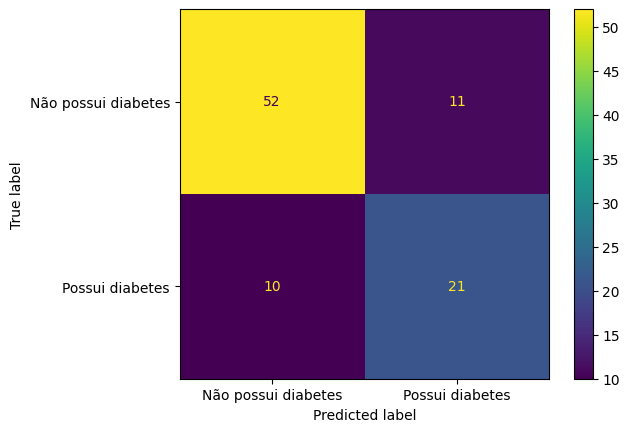

In [ ]:
y_previsto_decision_tree = decision_tree.predict(x_val_desafio)

matriz_confusao_decision_tree = confusion_matrix(y_val_desafio, y_previsto_decision_tree)
ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_decision_tree, display_labels=['Não possui diabetes', 'Possui diabetes']).plot();

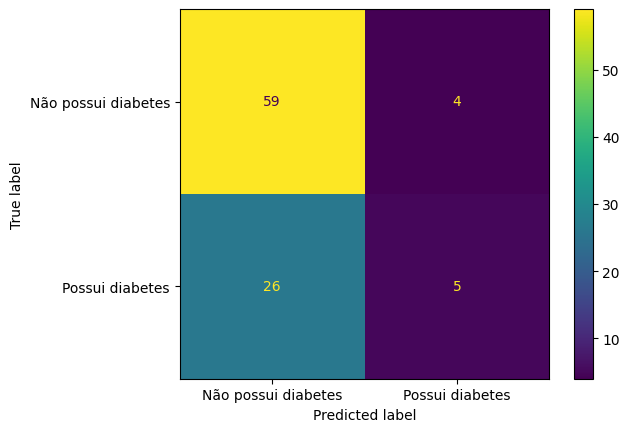

In [ ]:
y_previsto_random_forest = random_forest.predict(x_val_desafio)

matriz_confusao_random_forest = confusion_matrix(y_val_desafio, y_previsto_random_forest)
ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_random_forest, display_labels=['Não possui diabetes', 'Possui diabetes']).plot();

## Métricas de avaliação

1. Para uma avaliação completa de um modelo de classificação, podemos explorar métricas que avaliam a taxa de acerto geral e também para cada classe da variável alvo de forma individual. Extraia as métricas acurácia, recall, precisão e F1-Score dos modelos de classificação gerados no desafio da aula 1. A biblioteca Scikit-Learn possui funções para calcular cada uma das métricas, bastando fazer a importação e utilizar como parâmetros os valores reais e previstos pelo modelo.

In [ ]:
print(f"Acurácia (Decion Tree): {accuracy_score(y_val_desafio, y_previsto_decision_tree) * 100:.2f}%")
print(f"Precisão (Decion Tree): {precision_score(y_val_desafio, y_previsto_decision_tree) * 100:.2f}%")
print(f"Recall (Decion Tree): {recall_score(y_val_desafio, y_previsto_decision_tree) * 100:.2f}%")
print(f"F1-Score (Decion Tree): {f1_score(y_val_desafio, y_previsto_decision_tree) * 100:.2f}%\n")

Acurácia (Decion Tree): 77.66%
Precisão (Decion Tree): 65.62%
Recall (Decion Tree): 67.74%
F1-Score (Decion Tree): 66.67%



In [ ]:
print(f"Acurácia (Random Forest): {accuracy_score(y_val_desafio, y_previsto_random_forest) * 100:.2f}%")
print(f"Precisão (Random Forest): {precision_score(y_val_desafio, y_previsto_random_forest) * 100:.2f}%")
print(f"Recall (Random Forest): {recall_score(y_val_desafio, y_previsto_random_forest) * 100:.2f}%")
print(f"F1-Score (Random Forest): {f1_score(y_val_desafio, y_previsto_random_forest) * 100:.2f}%")

Acurácia (Random Forest): 68.09%
Precisão (Random Forest): 55.56%
Recall (Random Forest): 16.13%
F1-Score (Random Forest): 25.00%


2. Além de métricas numéricas, gráficos podem ser explorados para avaliar o desempenho de um modelo e compreender se ele consegue diferenciar bem uma classe da outra. Obtenha a curva ROC e a métrica AUC dos modelos de classificação gerados no desafio da aula 1, comparando as curvas no mesmo gráfico. A curva ROC pode ser gerada usando o método RocCurveDisplay.from_predictions.

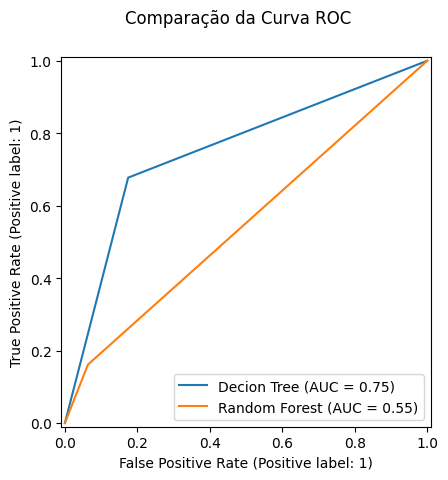

In [ ]:
roc_decision_tree = RocCurveDisplay.from_predictions(y_val_desafio, y_previsto_decision_tree, name='Decion Tree')
roc_random_forest = RocCurveDisplay.from_predictions(y_val_desafio, y_previsto_random_forest, name='Random Forest', ax=roc_decision_tree.ax_)
roc_random_forest.figure_.suptitle('Comparação da Curva ROC');

In [ ]:
print(f"AUC (Decion Tree): {roc_auc_score(y_val_desafio, y_previsto_decision_tree) * 100:.2f}%")
print(f"AUC (Random Forest): {roc_auc_score(y_val_desafio, y_previsto_random_forest) * 100:.2f}%")

AUC (Decion Tree): 75.14%
AUC (Random Forest): 54.89%


3. Além da curva ROC, a curva de precisão x recall pode ser usada para avaliar o desempenho de modelos, sendo mais interessante para dados desbalanceados. Obtenha a curva precisão x recall e a métrica AP dos modelos de classificação gerados no desafio da aula 1, comparando as curvas no mesmo gráfico. A curva precisão x recall pode ser gerada usando o método PrecisionRecallDisplay.from_predictions.

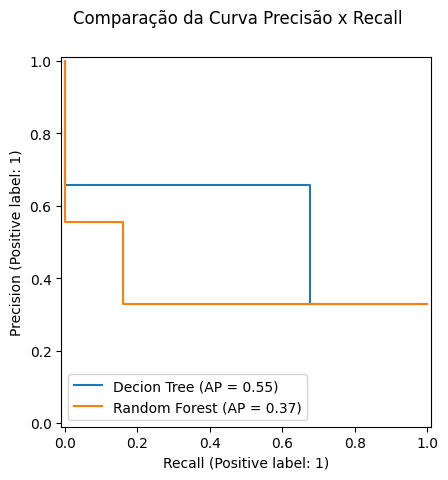

In [ ]:
precision_recall_decision_tree = PrecisionRecallDisplay.from_predictions(y_val_desafio, y_previsto_decision_tree, name='Decion Tree')
precision_recall_random_forest = PrecisionRecallDisplay.from_predictions(y_val_desafio, y_previsto_random_forest, name='Random Forest', ax=precision_recall_decision_tree.ax_)
precision_recall_random_forest.figure_.suptitle('Comparação da Curva Precisão x Recall');

In [ ]:
print(f"AP (Decion Tree): {average_precision_score(y_val_desafio, y_previsto_decision_tree) * 100:.2f}%")
print(f"AP (Random Forest): {average_precision_score(y_val_desafio, y_previsto_random_forest) * 100:.2f}%")

AP (Decion Tree): 55.09%
AP (Random Forest): 36.62%


4. Um resumo das principais métricas de classificação pode ser muito útil para sumarizar as informações e gerar insights de forma rápida. Gere os relatórios de métricas dos modelos de classificação construídos no desafio da aula 1. O relatório de métricas pode ser gerado a partir da função classification_report da biblioteca Scikit-Learn.

In [ ]:
print(classification_report(y_val_desafio, y_previsto_decision_tree))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83        63
           1       0.66      0.68      0.67        31

    accuracy                           0.78        94
   macro avg       0.75      0.75      0.75        94
weighted avg       0.78      0.78      0.78        94



In [ ]:
print(classification_report(y_val_desafio, y_previsto_random_forest))

              precision    recall  f1-score   support

           0       0.69      0.94      0.80        63
           1       0.56      0.16      0.25        31

    accuracy                           0.68        94
   macro avg       0.62      0.55      0.52        94
weighted avg       0.65      0.68      0.62        94



## Validação cruzada

1. No processo de validação cruzada, são gerados diferentes modelos para cada divisão realizada nos dados e consequentemente diferentes valores de métricas de avaliação. Para encontrar um resultado médio das métricas, pode ser construído um intervalo de confiança a partir da média e desvio padrão das métricas. Crie uma função para calcular o intervalo de confiança dos resultados de uma validação cruzada com 2 desvios padrão. A função precisa de 2 parâmetros: um para receber uma lista com os resultados das métricas da validação cruzada e outro para receber o nome do algoritmo. Para gerar o intervalo de confiança, extraia a média dos resultados da lista e o desvio padrão. O intervalo de confiança deve ser apresentado em um print com o valor mínimo sendo a média subtraída de 2 desvios padrão e o valor máximo sendo a média somada de 2 desvios padrão.

In [ ]:
def intervalo_confianca(resultados, modelo):
  media = resultados.mean()
  desvio_padrao = resultados.std()

  print(f"Intervalo de confiança ({modelo}): {media:.4f} [{media - 2 * desvio_padrao} - {media + 2 * desvio_padrao}]")

2. KFold é a estratégia mais simples de validação cruzada, que permite a divisão aleatória dos dados em k partes, sendo utilizada uma parte para validação e o restante para treinamento do modelo. O processo de criação de modelos é feito novamente até que todas as partes sejam utilizadas como validação. Sabendo disso, avalie o desempenho dos modelos com um intervalo de confiança utilizando a validação cruzada com o método KFold, usando 10 partes, com uso do parâmetro n_splits e embaralhando os dados antes da separação com o parâmetro shuffle. Use o método cross_val_score que não retorna o tempo de execução, apenas as métricas.

In [ ]:
kf_desafio = KFold(n_splits=10, shuffle=True, random_state=5)

cv_resultados_dt_desafio = cross_val_score(decision_tree, x_desafio, y_desafio, cv=kf_desafio, scoring='recall')
cv_resultados_rf_desafio = cross_val_score(random_forest, x_desafio, y_desafio, cv=kf_desafio, scoring='recall')

intervalo_confianca(cv_resultados_dt_desafio, 'Decion Tree')
intervalo_confianca(cv_resultados_rf_desafio, 'Random Forest')

Intervalo de confiança (Decion Tree): 0.5051 [0.24650294120233524 - 0.76371073401134]
Intervalo de confiança (Random Forest): 0.2739 [-0.08883920837386722 - 0.63662309115775]


3. No processo de divisão de dados com o KFold aleatório, pode ser que a proporção de cada categoria da variável alvo não seja mantida em cada uma das partes dos dados. Para manter essa proporção em cada uma das partes, podemos utilizar o KFold estratificado, deixando o processo de validação de dados bem mais consistente. Avalie o desempenho dos modelos com um intervalo de confiança utilizando a validação cruzada (cross_val_score) com o método StratifiedKFold, com uso do parâmetro n_splits e embaralhando os dados antes da separação com o parâmetro shuffle e avaliando a métrica F1-Score usando o parâmetro scoring.

In [ ]:
skf_desafio = StratifiedKFold(n_splits=10, shuffle=True, random_state=5)

cv_resultados_dt_desafio = cross_val_score(decision_tree, x_desafio, y_desafio, cv=skf_desafio, scoring='f1')
cv_resultados_rf_desafio = cross_val_score(random_forest, x_desafio, y_desafio, cv=skf_desafio, scoring='f1')

intervalo_confianca(cv_resultados_dt_desafio, 'Decion Tree')
intervalo_confianca(cv_resultados_rf_desafio, 'Random Forest')

Intervalo de confiança (Decion Tree): 0.5018 [0.2681981750463088 - 0.7354166140441551]
Intervalo de confiança (Random Forest): 0.3335 [0.09383782507593422 - 0.5732559274048152]


4. Em conjuntos de dados com poucos registros (poucas linhas), as estratégias de separação dos dados para validação podem fazer com que reste pouca informação nos dados de treinamento, fazendo com que o modelo não compreenda bem o padrão dos dados. O LeaveOneOut é uma estratégia para contornar esse problema, utilizando apenas um registro como dado de validação. Avalie o desempenho dos modelos utilizando a validação cruzada (cross_val_score) com o método LeaveOneOut.

In [ ]:
loo = LeaveOneOut()

recall_scorer = make_scorer(recall_score, zero_division=1)

cv_resultados_dt_desafio = cross_validate(decision_tree, x_desafio, y_desafio, cv=loo, scoring=recall_scorer)
cv_resultados_rf_desafio = cross_validate(random_forest, x_desafio, y_desafio, cv=loo, scoring=recall_scorer)

print(f"Recall médio (Decion Tree): {cv_resultados_dt_desafio['test_score'].mean() * 100:.2f}%")
print(f"Recall médio (Random Forest): {cv_resultados_rf_desafio['test_score'].mean() * 100:.2f}%")

Recall médio (Decion Tree): 79.14%
Recall médio (Random Forest): 75.13%


In [ ]:
loo = LeaveOneOut()

recall_scorer = make_scorer(recall_score, zero_division=0)

cv_resultados_dt_desafio = cross_validate(decision_tree, x_desafio, y_desafio, cv=loo, scoring=recall_scorer)
cv_resultados_rf_desafio = cross_validate(random_forest, x_desafio, y_desafio, cv=loo, scoring=recall_scorer)

print(f"Recall médio (Decion Tree): {cv_resultados_dt_desafio['test_score'].mean() * 100:.2f}%")
print(f"Recall médio (Random Forest): {cv_resultados_rf_desafio['test_score'].mean() * 100:.2f}%")

Recall médio (Decion Tree): 12.03%
Recall médio (Random Forest): 7.22%


## Balanceamento de dados

1. O desbalanceamento dos dados da variável alvo pode fazer com que o modelo fique tendencioso a acertar os padrões de apenas da categoria que tem maior quantidade, tornando necessário em alguns casos um tratamento específico de balanceamento de dados. A etapa inicial é identificar se existe ou não o desbalanceamento de dados na variável alvo. Por conta disso, verifique a proporção de dados da variável alvo do conjunto de dados de diabetes. Essa análise pode ser feita a partir da porcentagem de dados, usando o método value_counts(normalize=True) ou com a utilização de um gráfico de contagem, usando o gráfico countplot da biblioteca seaborn para entender se há um desbalanceamento de dados.

In [ ]:
dados_desafio['diabetes'].value_counts(normalize=True)

,proportion
diabetes,
0,0.670051
1,0.329949


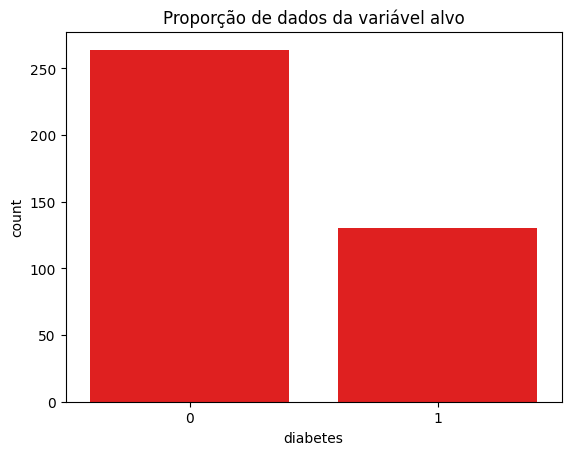

In [ ]:
ax = sns.countplot(dados_desafio, x='diabetes', color='red')
ax.set_title('Proporção de dados da variável alvo');

2. Ao realizar o balanceamento de dados em uma validação cruzada, é necessário utilizar um pipeline, para que os dados de validação não sejam balanceados, se mantendo no padrão dos dados do mundo real. Utilize um pipeline contendo ajuste do modelo e o balanceamento dos dados usando o oversampling com SMOTE, obtendo a média do F1-Score de uma validação cruzada com StratifiedKFold.

In [ ]:
skf_desafio = StratifiedKFold(n_splits=10, shuffle=True, random_state=5)

In [ ]:
pipeline_dt = imbpipeline([('oversample', SMOTE()), ('arvore', decision_tree)])

cv_resultados_dt_desafio = cross_val_score(pipeline_dt, x_desafio, y_desafio, cv=skf_desafio, scoring='f1')

intervalo_confianca(cv_resultados_dt_desafio, 'Decion Tree')

Intervalo de confiança (Decion Tree): 0.5867 [0.45676290181785906 - 0.716700857355619]


In [ ]:
pipeline_rf = imbpipeline([('oversample', SMOTE()), ('arvore', random_forest)])

cv_resultados_rf_desafio = cross_val_score(pipeline_rf, x_desafio, y_desafio, cv=skf_desafio, scoring='f1')

intervalo_confianca(cv_resultados_rf_desafio, 'Random Forest')

Intervalo de confiança (Random Forest): 0.6104 [0.49485382730687477 - 0.7259169818071227]


3. Além do oversampling, é possível utilizar a estratégia de undersampling para fazer o balanceamento dos dados. Apesar de serem estratégias distintas, ambas necessitam de um pipeline por se tratar de balanceamento de dados em uma validação cruzada. Utilize um pipeline contendo ajuste do modelo e o balanceamento dos dados usando o undersampling com NearMiss na sua versão 3, obtendo a média do F1-Score de uma validação cruzada com StratifiedKFold.

In [ ]:
pipeline_dt = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', decision_tree)])

cv_resultados_dt_desafio = cross_val_score(pipeline_dt, x_desafio, y_desafio, cv=skf_desafio, scoring='f1')

intervalo_confianca(cv_resultados_dt_desafio, 'Decion Tree')

Intervalo de confiança (Decion Tree): 0.5450 [0.33350896769534044 - 0.7564273269990187]


In [ ]:
pipeline_rf = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', random_forest)])

cv_resultados_rf_desafio = cross_val_score(pipeline_rf, x_desafio, y_desafio, cv=skf_desafio, scoring='f1')

intervalo_confianca(cv_resultados_rf_desafio, 'Random Forest')

Intervalo de confiança (Random Forest): 0.6188 [0.4997817252799197 - 0.737853066947695]


4. Após realizar diversas análises e aprimorar o desempenho dos modelos, chega a etapa final, que consiste em selecionar o modelo com melhor desempenho e fazer a avaliação final em um conjunto de dados de teste, que não foi visto durante o processo de treinamento e validação. Escolha o modelo que obteve o melhor desempenho ao comparar as estratégias de oversampling e undersampling e treine um modelo usando todos os dados com a melhor estratégia. Realize a avaliação do modelo usando os dados de teste que foram separados no início dos desafios, obtendo o relatório de métricas e matriz de confusão.

              precision    recall  f1-score   support

           0       0.80      0.62      0.70        13
           1       0.50      0.71      0.59         7

    accuracy                           0.65        20
   macro avg       0.65      0.66      0.64        20
weighted avg       0.70      0.65      0.66        20



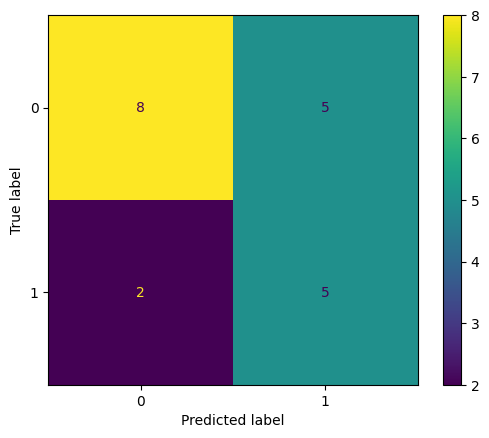

In [ ]:
undersample_desafio = NearMiss(version=3)
x_balanceado_desafio, y_balanceado_desafio = undersample_desafio.fit_resample(x_desafio, y_desafio)

modelo_desafio = random_forest
modelo_desafio.fit(x_balanceado_desafio, y_balanceado_desafio)
y_previsto_desafio = modelo_desafio.predict(x_teste_desafio)

print(classification_report(y_teste_desafio, y_previsto_desafio))
ConfusionMatrixDisplay.from_predictions(y_teste_desafio, y_previsto_desafio);